In [1]:
import sys
sys.path.append('../src')

In [2]:
from integrator import ComplexIntegrator
from context_manager import TriangleIntegrandContext, TriangleIntegrandEvaluator, spherical
from wrapped_eval import WrappedEvaluator
from integrand_builder import IntegrandBuilder
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from symbolica import RandomNumberGenerator

# do this to trigger the banner here so it doesn't get in the way later
import oneloop_bridge
oneloop_bridge.set_renormalization_scale(1.0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
ib.check_singularities = False  # Not necessary for this example, improves runtime
ib.subtract_only_existing_surfaces = True
ctx.set_external_momenta(1, 1, 4)
full_integrand = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "full_integrand"), ctx
)
ib.subtract_only_existing_surfaces = False
full_integrand_unchecked = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "full_unchecked"), ctx
)

Compiling evaluator: "full_integrand"
Done!
Compiling evaluator: "full_unchecked"
Done!


# plot the integrand and threshold subtraction

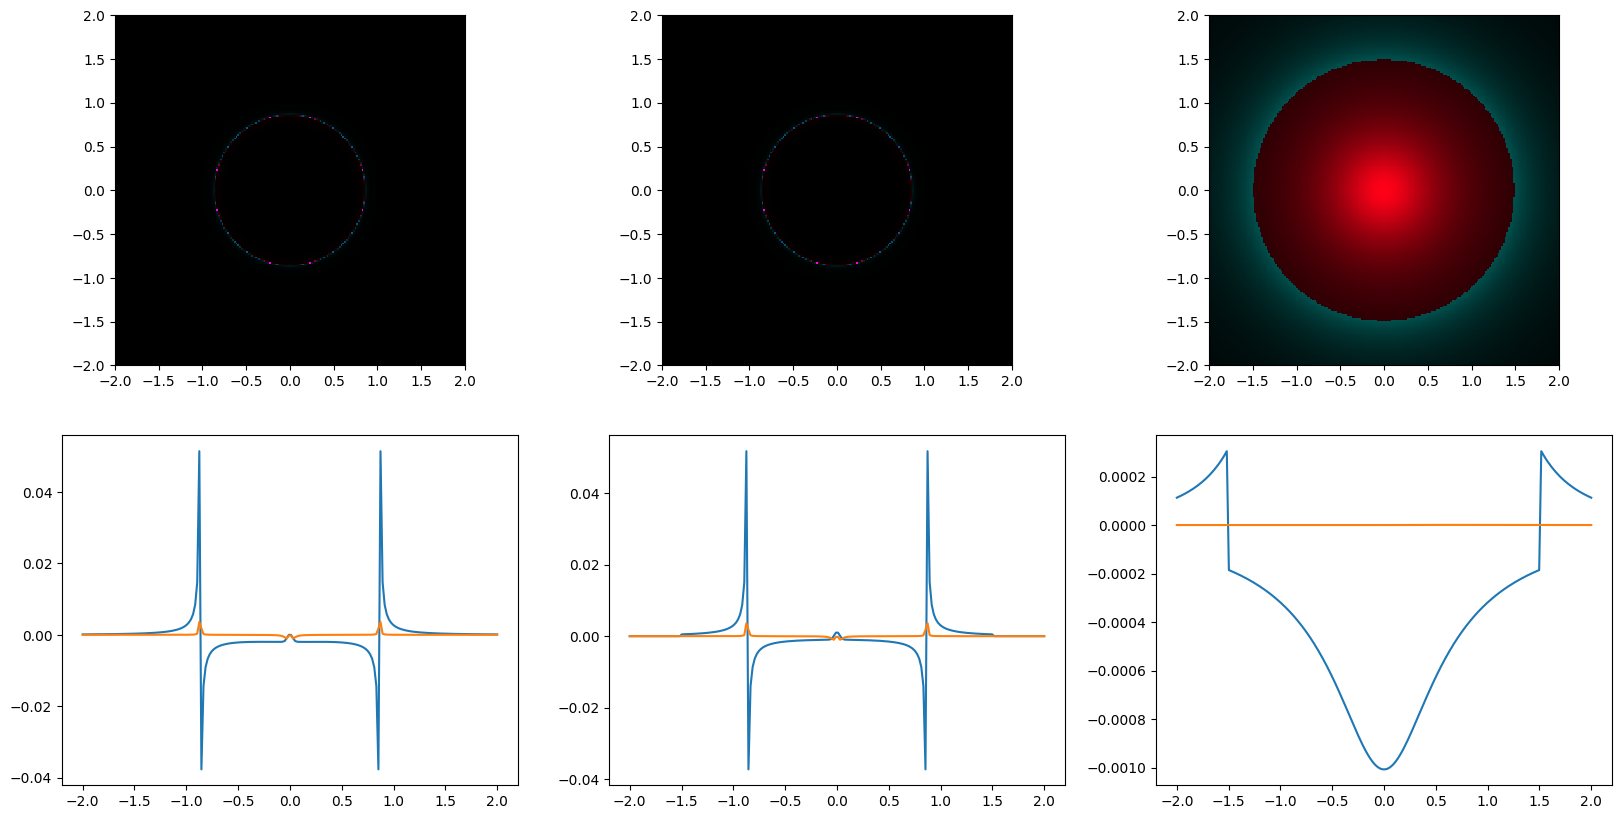

In [4]:
real_mass = 0.5
ctx.masses = [real_mass-0.001j, real_mass-0.001j, real_mass-0.001j]
ctx.threshold = 1.5

full_integrand.plot_threshold_subtraction((-2,2),(-2,2))

In [5]:
rng = RandomNumberGenerator(0,0)

In [6]:
def integrate_over_masses(masses, triangle):
    results = []
    real_err = []
    imag_err = []
    convergence = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        result = ci.integrate(triangle.eval, spherical, 50, 200, rng)
        results.append(result.real_avg + 1j*result.imag_avg)
        real_err.append(result.real_err)
        imag_err.append(result.imag_err)
        convergence.append(result.convergence())
        
    return np.array(results), np.array(real_err), np.array(imag_err), np.array(convergence)

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [7]:
sample_masses = real_mass - 0.08j*0.001**np.linspace(0,1,15)
reference_masses = real_mass - 0.08j*0.001**np.linspace(0,1,50)

ctx.combined_integrand()
combined_res = integrate_over_masses(sample_masses, full_integrand)


ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, full_integrand)

ref = reference_over_masses(reference_masses)

100%|██████████| 15/15 [00:03<00:00,  3.88it/s]


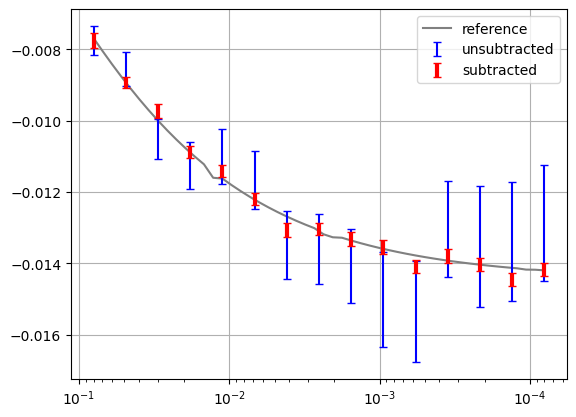

In [8]:
plt.plot(-reference_masses.imag, ref.real, label="reference", c="gray")
plt.errorbar(
    -sample_masses.imag,
    unsub_res[0].real,
    unsub_res[1],
    ls="",
    capsize=3,
    label="unsubtracted",
    c="blue",
)
plt.errorbar(
    -sample_masses.imag,
    combined_res[0].real,
    combined_res[1],
    ls="",
    capsize=3,
    elinewidth=3,
    label="subtracted",
    c="red",
)
plt.xscale("log")
plt.gca().xaxis.set_inverted(True)
plt.grid(True)
plt.legend()
plt.show()

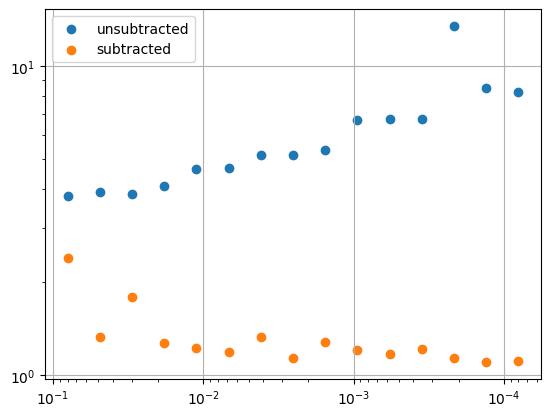

In [9]:

plt.scatter(-sample_masses.imag, unsub_res[-1], label = 'unsubtracted')
plt.scatter(-sample_masses.imag, combined_res[-1], label = 'subtracted')
plt.xscale('log')
plt.yscale('log')
plt.gca().xaxis.set_inverted(True)
plt.grid(True)
plt.legend()
plt.show()


In [10]:
sample_masses = np.linspace(0.5,3,20)
reference_masses = np.linspace(0.5,3,100)

ctx.combined_integrand()
combined_res = integrate_over_masses(sample_masses, full_integrand)
unchecked_res = integrate_over_masses(sample_masses, full_integrand_unchecked)

ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, full_integrand)

ref = reference_over_masses(reference_masses)

100%|██████████| 20/20 [00:04<00:00,  4.04it/s]


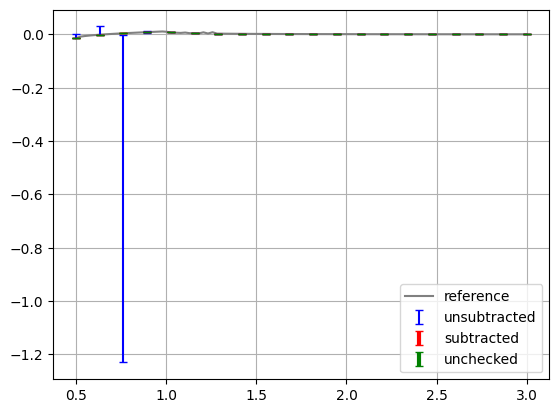

In [11]:
plt.plot(reference_masses, ref.real, label="reference", c="gray")
plt.errorbar(
    sample_masses,
    unsub_res[0].real,
    unsub_res[1],
    ls="",
    capsize=3,
    label="unsubtracted",
    c="blue",
)
plt.errorbar(
    sample_masses,
    combined_res[0].real,
    combined_res[1],
    ls="",
    capsize=3,
    elinewidth=3,
    label="subtracted",
    c="red",
)
plt.errorbar(
    sample_masses,
    unchecked_res[0].real,
    unchecked_res[1],
    ls="",
    capsize=3,
    elinewidth=3,
    label="unchecked",
    c="green",)
plt.grid(True)
plt.legend()
plt.show()

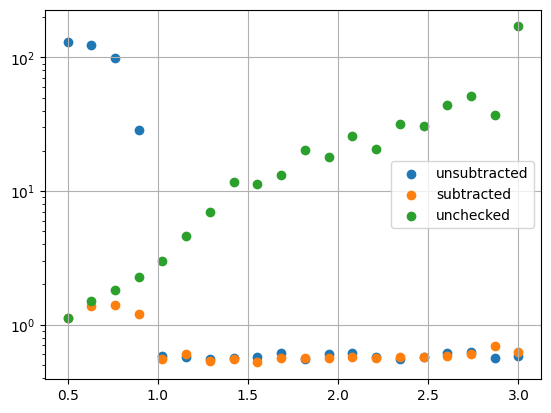

In [12]:
plt.scatter(sample_masses, unsub_res[-1], label = 'unsubtracted')
plt.scatter(sample_masses, combined_res[-1], label = 'subtracted')
plt.scatter(sample_masses, unchecked_res[-1], label = 'unchecked')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()


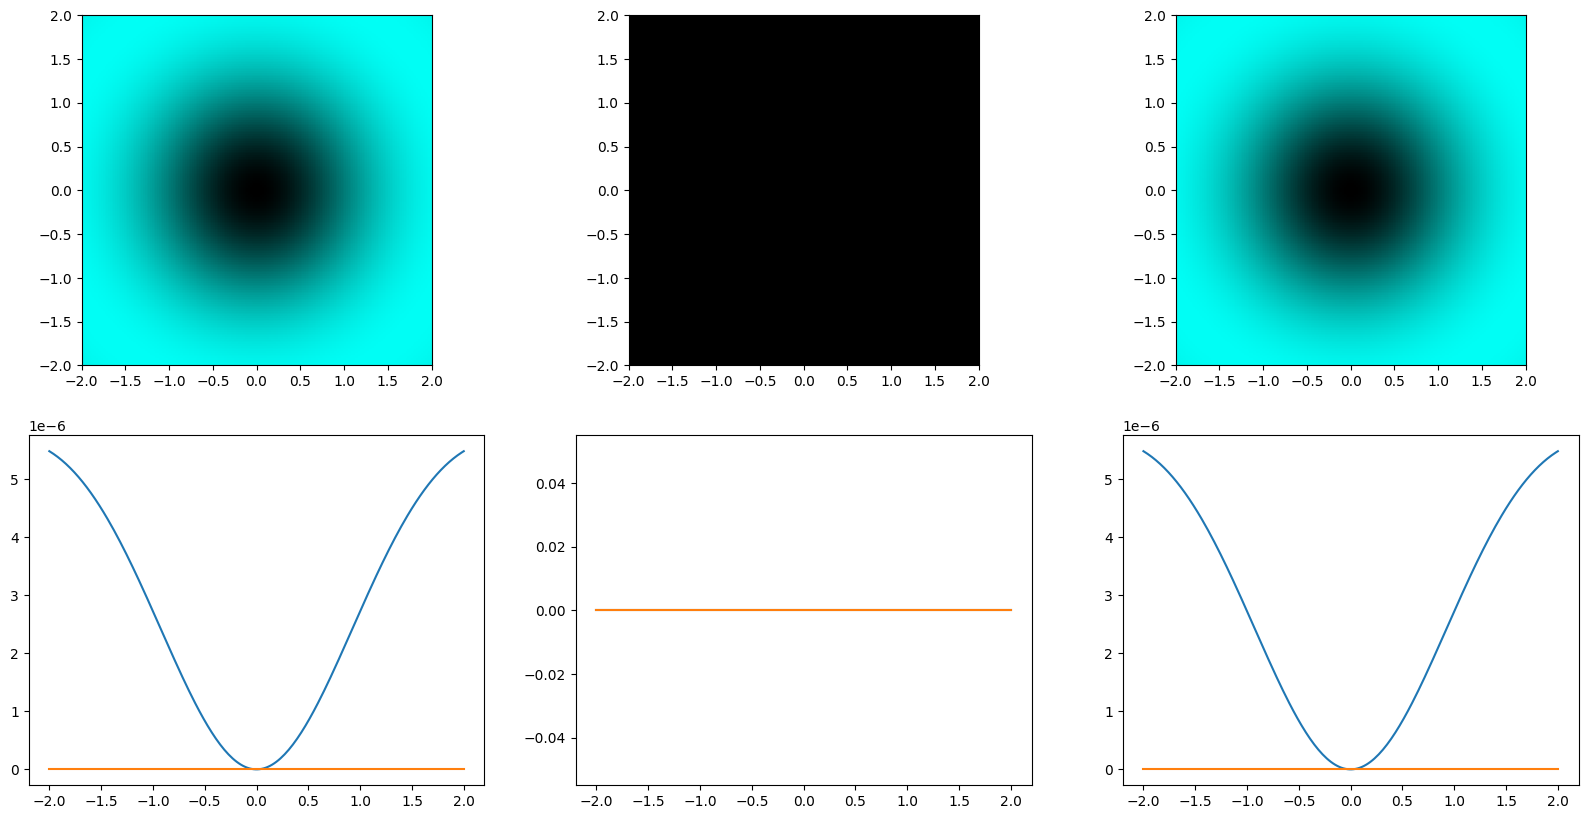

In [13]:
full_integrand.plot_threshold_subtraction((-2,2),(-2,2))